# 00 - Generate the training dataset

Bulk-generates sticker photos via `label-generator-api` (must already be
running - `make run-label-generator-api` from the repo root, or `make
start-all`), using its `include_manifest` option to get ground-truth geometry
(rotation angle + sticker corner points) alongside the images.

Two SKU populations, both in one combined dataset:

- The **real 20-item product catalog** (`../products.csv`) - always held out
  of training for every stage, so `04_end_to_end_pipeline.ipynb` measures
  something meaningful (accuracy on SKUs the pipeline never saw).
- A **larger synthetic vocabulary** (`SKU-` + random 4-digit numbers outside
  the catalog's range) - so the OCR stage in particular learns to read
  characters instead of memorizing 20 classes.

Produces `data/raw/manifest.jsonl` (all images + ground truth) and
`data/raw/splits.json` (SKU -> split assignment), which notebooks 01-03
load directly.

In [1]:
import sys
from pathlib import Path


def _find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "requirements.txt").is_file():
            return candidate
    raise RuntimeError("Could not locate the vision-ml project root from " + str(start))


PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT


PosixPath('/Users/lroland/Projects/github.com/distribution-center/vision-ml')

In [2]:
import csv
import json
import random

import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

from src import client, datasets, geometry, settings

random.seed(0)


## Build the SKU list

In [3]:
with open(PROJECT_ROOT.parent / "products.csv") as f:
    catalog_skus = [row["sku"] for row in csv.DictReader(f)]

print(f"{len(catalog_skus)} catalog SKUs:", catalog_skus[:5], "...")

# Sample synthetic SKU numbers from the *same* 4-digit range the catalog lives in
# (1000-9999), only excluding the 20 exact catalog numbers - not the whole 1000s decade.
# An earlier version of this notebook sampled synthetic numbers from 2000-9999 only, which
# seemed like a safe way to avoid overlap but actually meant the OCR model never saw a single
# training example with a leading "1" digit - it consistently misread real SKU-10xx catalog
# stickers as a result (e.g. "SKU-1010" -> "SKU-8118"), 0% catalog accuracy despite 84% on the
# synthetic split. Held-out-ness only requires excluding the exact catalog *numbers*, not their
# whole numeric neighborhood.
CATALOG_QTY_PER_SKU = 40
SYNTHETIC_NUM_SKUS = 800
SYNTHETIC_QTY_PER_SKU = 8

catalog_numbers = {int(sku.split("-")[1]) for sku in catalog_skus}
candidate_numbers = [n for n in range(1000, 10000) if n not in catalog_numbers]
synthetic_numbers = random.sample(candidate_numbers, SYNTHETIC_NUM_SKUS)
synthetic_skus = [f"SKU-{n}" for n in synthetic_numbers]

items = [(sku, CATALOG_QTY_PER_SKU) for sku in catalog_skus] + [
    (sku, SYNTHETIC_QTY_PER_SKU) for sku in synthetic_skus
]
total_images = sum(qty for _, qty in items)
print(f"{len(items)} distinct SKUs, {total_images} images total")


20 catalog SKUs: ['SKU-1001', 'SKU-1002', 'SKU-1003', 'SKU-1004', 'SKU-1005'] ...
820 distinct SKUs, 7200 images total


## Generate

This calls `/stickers/bulk` in batches of <=200 distinct SKUs each (the endpoint's own limit) - a few requests, each returning hundreds of images. Expect this to take a couple of minutes.

In [4]:
manifest_path = client.download_dataset(items, dest_dir=settings.RAW_DIR)
manifest_path


PosixPath('/Users/lroland/Projects/github.com/distribution-center/vision-ml/data/raw/manifest.jsonl')

In [5]:
records = datasets.load_manifest(manifest_path)
print(f"{len(records)} images generated")

from collections import Counter
color_counts = Counter(r["color_mode"] for r in records)
print("color_mode distribution:", dict(color_counts))
print("canvas width range:", min(r["canvas_width"] for r in records), "-", max(r["canvas_width"] for r in records))
print("canvas height range:", min(r["canvas_height"] for r in records), "-", max(r["canvas_height"] for r in records))


7200 images generated
color_mode distribution: {'color': 5047, 'bw': 2153}
canvas width range: 480 - 900
canvas height range: 360 - 700


## Verify the ground-truth geometry

**Do not skip this.** Everything downstream (bbox targets, angle targets,
de-rotated OCR crops) is derived from `corners_xy` - if that's wrong, every
model trains on wrong labels and none of it will be obvious until much later.
Overlay the corners on a handful of raw images, and separately render the
de-rotated crop, and eyeball that both look right.

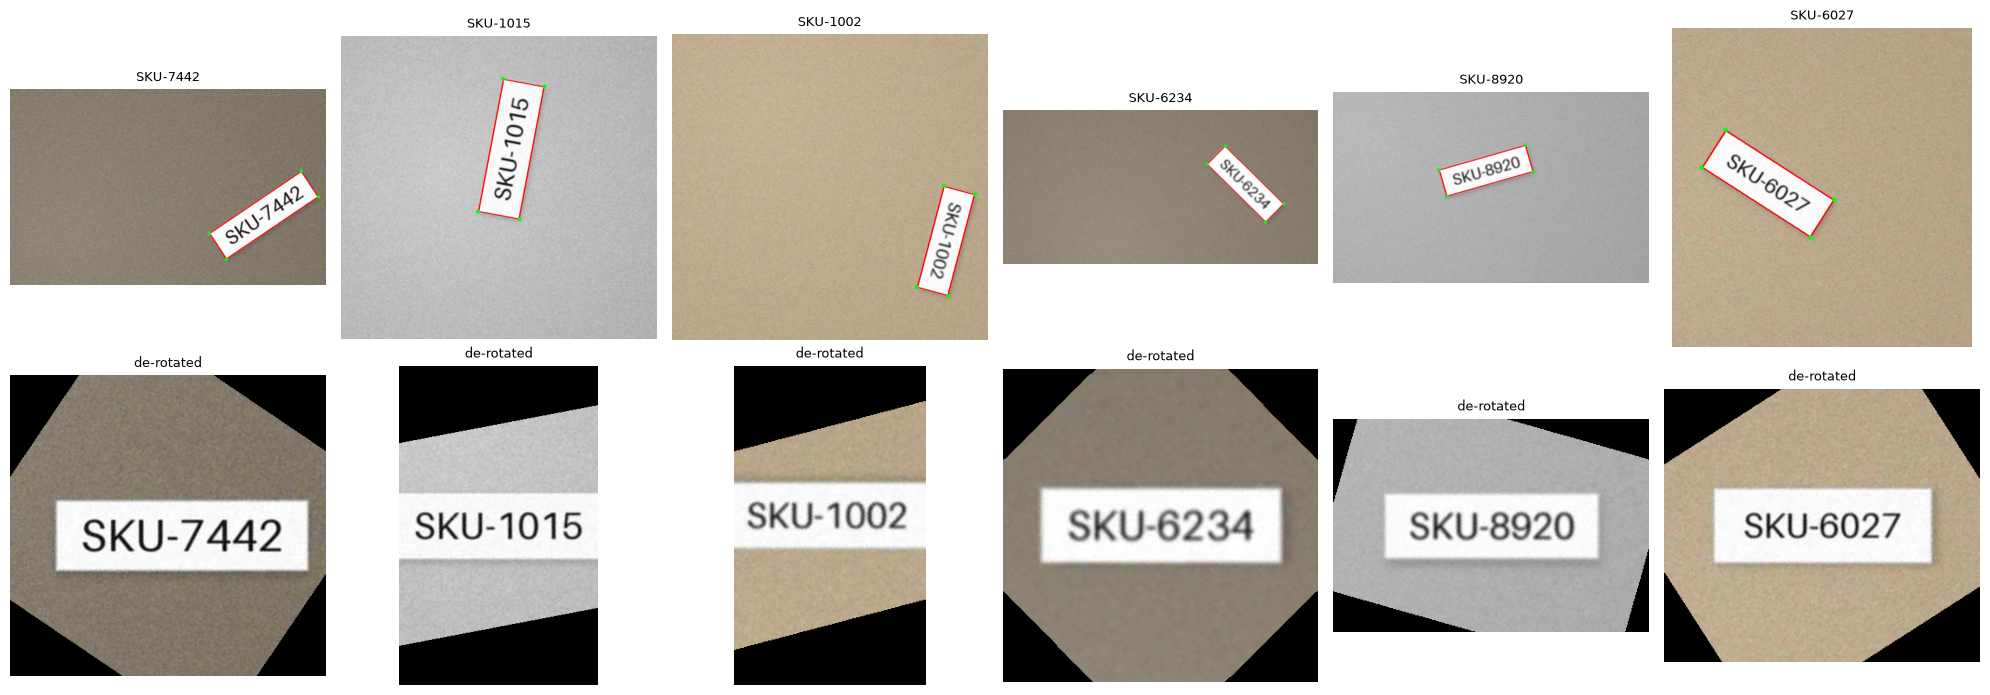

In [6]:
sample = random.sample(records, 6)

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
for col, record in enumerate(sample):
    image = Image.open(settings.RAW_DIR / record["image_path"]).convert("RGB")

    overlay = image.copy()
    draw = ImageDraw.Draw(overlay)
    corners = record["corners_xy"]
    draw.polygon(corners, outline=(255, 0, 0), width=3)
    for x, y in corners:
        draw.ellipse([x - 4, y - 4, x + 4, y + 4], fill=(0, 255, 0))
    axes[0, col].imshow(overlay)
    axes[0, col].set_title(record["sku"], fontsize=9)
    axes[0, col].axis("off")

    bbox = geometry.corners_to_bbox(corners)
    canvas_size = (record["canvas_width"], record["canvas_height"])
    padded = geometry.pad_bbox(bbox, 0.2, canvas_size)
    crop = image.crop(padded)
    angle = geometry.corners_to_angle_degrees(corners)
    upright = geometry.rotate_upright(crop, angle)
    axes[1, col].imshow(upright)
    axes[1, col].set_title("de-rotated", fontsize=9)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("corners_xy overlay", fontsize=10)
axes[1, 0].set_ylabel("rotate_upright output", fontsize=10)
plt.tight_layout()
plt.show()


The top row's red/green overlay should trace each sticker's actual edges and corners exactly. The bottom row should read horizontally, right-side up, for every sample. If either doesn't hold, stop here - don't train on top of broken geometry.

## Build train/val/test splits

SKU-level: the real catalog is always held out (routed to `test`); the synthetic vocabulary is split so `train`/`val` never share a SKU with `test` either, since the OCR stage needs to be judged on genuinely unseen strings.

In [7]:
train_records, val_records, test_records = datasets.split_records(
    records, val_frac=0.1, test_frac=0.05, seed=0, held_out_skus=catalog_skus
)

print(f"train: {len(train_records)} images, {len({r['sku'] for r in train_records})} SKUs")
print(f"val:   {len(val_records)} images, {len({r['sku'] for r in val_records})} SKUs")
print(f"test:  {len(test_records)} images, {len({r['sku'] for r in test_records})} SKUs "
      f"(includes all {len(catalog_skus)} catalog SKUs)")

splits = {
    "train_skus": sorted({r["sku"] for r in train_records}),
    "val_skus": sorted({r["sku"] for r in val_records}),
    "test_skus": sorted({r["sku"] for r in test_records}),
    "catalog_skus": catalog_skus,
}
splits_path = settings.RAW_DIR / "splits.json"
splits_path.write_text(json.dumps(splits, indent=2))
print("wrote", splits_path)


train: 5440 images, 680 SKUs
val:   640 images, 80 SKUs
test:  1120 images, 60 SKUs (includes all 20 catalog SKUs)
wrote /Users/lroland/Projects/github.com/distribution-center/vision-ml/data/raw/splits.json


Notebooks 01-03 each load `manifest.jsonl` + `splits.json` and build their own stage-specific `(input, target)` pairs from them via `geometry.py` - see `src/datasets.py`.